# Compare the preprocessing and MEIs generated if the data from the session were presented online

### generate meis with pretrained model

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any

from IPython.display import display



In [4]:
# Load config
import sys
import os
from pathlib import Path


# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))



home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config
Configuration loaded successfully:
data_subfolders:
  day: 20250717
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/klaudia_data_test
  table_parameters:
    PreprocessParams:
    - preprocess_id: 1
      fs_resample: 60
      stim_names:
      - chrip
      - mb
      - densenoise
    - preprocess_id: 2
      window_length: 60
      poly_order: 3
      non_negative: 1
      subtract_baseline: 0
      standardize: 1
      stim_names:
      - mouse_cam
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
        framerate: 5
    DNo

In [5]:
from simulations.loop_components.dj_wrappers import DJTableHolder,Preprocessor,QualityAndTypeWrapper,STAWrapper,RandomSeedMEIWrapper
# from simulations.loop_components.recording_file_copier import copy_rec_files,create_directory_structure
# from simulations.loop_components.stimulus import create_rf_avi_from_roi_ids, create_full_avi_from_roi_id_and_seed
# from simulations.loop_components.utils import log

In [6]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )



In [7]:

# Load config and tables
dj_table_holder.load_config()
dj_table_holder.load_tables()
# print(" loaded and configured successfully")
# dj_table_holder.clear_tables("all")

# dj_table_holder.setup()

[2025-08-18 14:54:04,182][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-08-18 14:54:04,239][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop


In [ ]:
preprocessor = Preprocessor(dj_table_holder=dj_table_holder)


quality_type_analysis_wrapper = QualityAndTypeWrapper(
    dj_table_holder=dj_table_holder,)

sta_wrapper = STAWrapper(
    dj_table_holder=dj_table_holder,)


In [9]:
# dj_table_holder.clear_tables("experiment")
# preprocessor.upload_iteration_metadata()

In [10]:
missing_keys = dj_table_holder("RoiMask")().list_missing_field()
missing_keys
field_key = missing_keys[0]

In [11]:
from simulations.gui.integrated_autorois import InteractiveRoiCanvas
# import ipywidgets as widgets
# from ipycanvas import MultiCanvas
from IPython.display import display     


In [81]:
online_analysis_gui = InteractiveRoiCanvas(
    dj_table_holder=dj_table_holder,
    dj_preprocessor=preprocessor,
    all_dj_wrappers=[quality_type_analysis_wrapper,sta_wrapper],
    field_key=field_key,
    canvas_width=30,
    )

Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


In [82]:
display(online_analysis_gui.start_gui())

# Extract OR data

In [41]:
dj_table_holder("CelltypeAssignment")() 

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),avg_stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,os_ds_stim_name Unique string identifier,training_data_hash hash of the classifier training data files,classifier_params_hash hash of the classifier params config,"celltype predicted group, without quality or confidence threshold",max_confidence confidence score for assigned celltype for easy restriction,confidence confidence score (probability) for all celltypes
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,1,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,46,0.227675,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,2,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,40,0.598459,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,3,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,7,0.136351,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,4,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,22,0.202907,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,5,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,1,0.367331,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,6,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,46,0.217036,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,7,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,17,0.43924,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,8,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,31,0.589163,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,9,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,14,0.177993,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,10,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,26,0.132294,=BLOB=


In [37]:

(dj_table_holder("PreprocessTraces")() & dict(stim_name="mouse_cam")).proj()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,1,2
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,2,2
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,3,2
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,4,2
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,5,2
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,6,2
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,7,2
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,8,2
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,9,2
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,mouse_cam,control,10,2


In [56]:
dj_table_holder("OpenRetinaHoeflingFormat")().delete()

[2025-08-18 17:38:49,438][INFO]: Deleting 1 rows from `ageuler_ssuhai_closed_loop`.`open_retina_hoefling_format`
--- Logging error ---
Traceback (most recent call last):
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/logging/__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
ValueError: I/O operation on closed file.
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/tornado/platform/asy

[2025-08-18 17:38:51,484][INFO]: Deletes committed.
--- Logging error ---
Traceback (most recent call last):
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/logging/__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
ValueError: I/O operation on closed file.
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_foreve

1

In [57]:
random_seed_mei_wrapper = RandomSeedMEIWrapper(
    dj_table_holder=dj_table_holder,
    model_configs=cfg.model_configs, 
    seeds= [123,456,789]) 

In [58]:
random_seed_mei_wrapper.compute_analysis()

Original dataset contains 103 neurons over 1 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (1 remaining)
Overall, dropped 13 neurons of non-target cell types (-12.62%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (1 remaining)
Overall, dropped 13 neurons over quality checks (-14.44%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 11 neurons with classifier confidences below 0.25 (-14.29%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 66 neurons over 1 fields
Total number of cells dropped: 37 (-35.92%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/1 [00:00<?, ?it/s]

Creating movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/gpfs01/euler/User/ssuhai/.local/lib/python3.12/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory output/csv/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/gpfs01/euler/User/ssuhai/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /gpfs01/euler/User/ssuhai/output/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃       DataLoader 1        ┃       DataLoader 2        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_correlation      │    0.28896573185920715    │    0.32106903195381165    │    0.4999138414859772     │
│         test_loss         │      921.65771484375      │     512.9786376953125     │     53.68632125854492     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

Seed set to 123


Function train_model_online took 33.824069 seconds to execute.


Seed set to 456
Seed set to 789


In [29]:
from openretina.utils.h5_handling import load_h5_into_dict
from openretina.data_io.hoefling_2024.responses import filter_responses, make_final_responses


In [30]:
# load OR data
responses_path = "/gpfs01/euler/User/ssuhai/openretina_cache/euler_lab/hoefling_2024/responses/rgc_natstim_2024-08-14.h5"

responses_dict = load_h5_into_dict(file_path=responses_path)

filtered_responses_dict = filter_responses(responses_dict, **cfg.model_configs.quality_checks)

final_responses = make_final_responses(filtered_responses_dict, response_type="natural")

Loading HDF5 file contents:   0%|          | 0/2077 [00:00<?, ?item/s]

Original dataset contains 7863 neurons over 67 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (67 remaining)
Overall, dropped 3034 neurons of non-target cell types (-38.59%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (67 remaining)
Overall, dropped 980 neurons over quality checks (-20.29%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 705 neurons with classifier confidences below 0.25 (-18.32%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 3144 neurons over 67 fields
Total number of cells dropped: 4719 (-60.02%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/67 [00:00<?, ?it/s]

In [21]:
import matplotlib.pyplot as plt
import numpy as np

In [97]:
random_seed_mei_wrapper 

# spike estimaiton similarity 

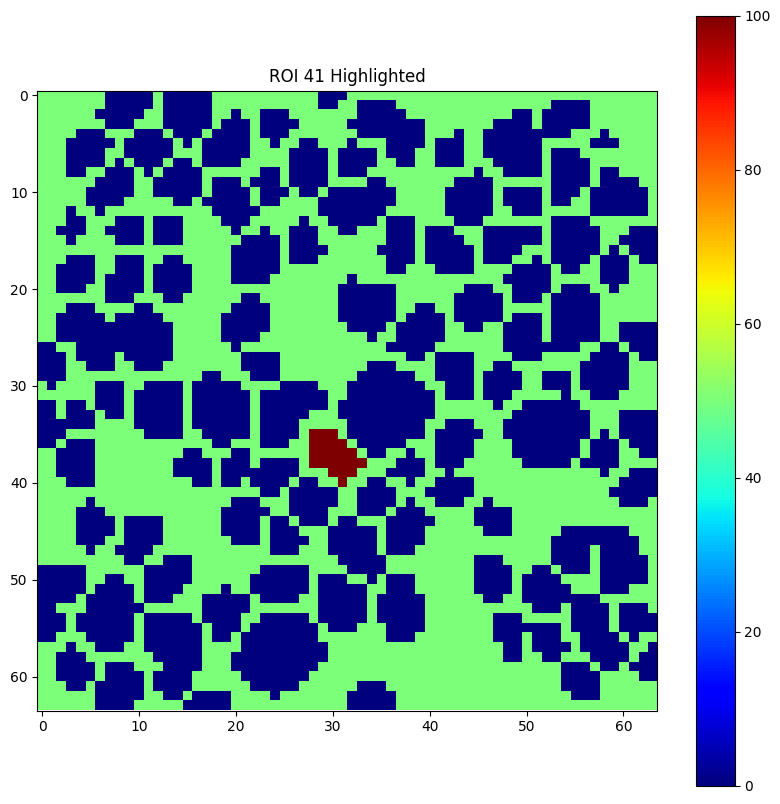

In [197]:
online_mask = dj_table_holder("RoiMask")().fetch1("roi_mask")

def show_highlighted_mask(mask, roi_id, ax=None):
    """
    Displays a mask with a specific ROI highlighted.
    
    Args:
        mask: The ROI mask array
        roi_id: The ROI ID to highlight
        ax: Optional matplotlib axis to plot on
    
    Returns:
        The matplotlib axis object
    """
    # Create highlighted mask: 
    # - Selected ROI gets value 100 (bright)
    # - All other ROIs get value 50 (medium)
    # - Background stays 0 (dark)
    highlighted_mask = (mask == -roi_id) * 100 + (mask > 0) * 50
    
    # Create figure if needed
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    # Display the mask with proper orientation
    im = ax.imshow(np.rot90(highlighted_mask), cmap='jet')
    
    # Add colorbar and title
    plt.colorbar(im, ax=ax)
    ax.set_title(f"ROI {roi_id} Highlighted")
    
    return ax

# Example usage
fig, ax = plt.subplots(figsize=(10, 10))
show_highlighted_mask(online_mask, 41, ax)
plt.show()

<Axes: title={'center': 'ROI 54 Highlighted'}>

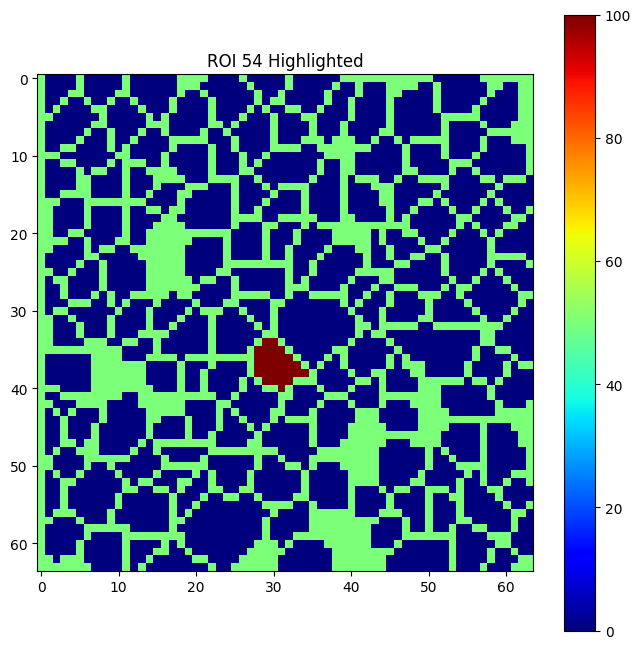

In [192]:
raw_session_dict = responses_dict['session_1_ventral1_20200226']
show_highlighted_mask(raw_session_dict["roi_mask"], 54)

0.936391143529347


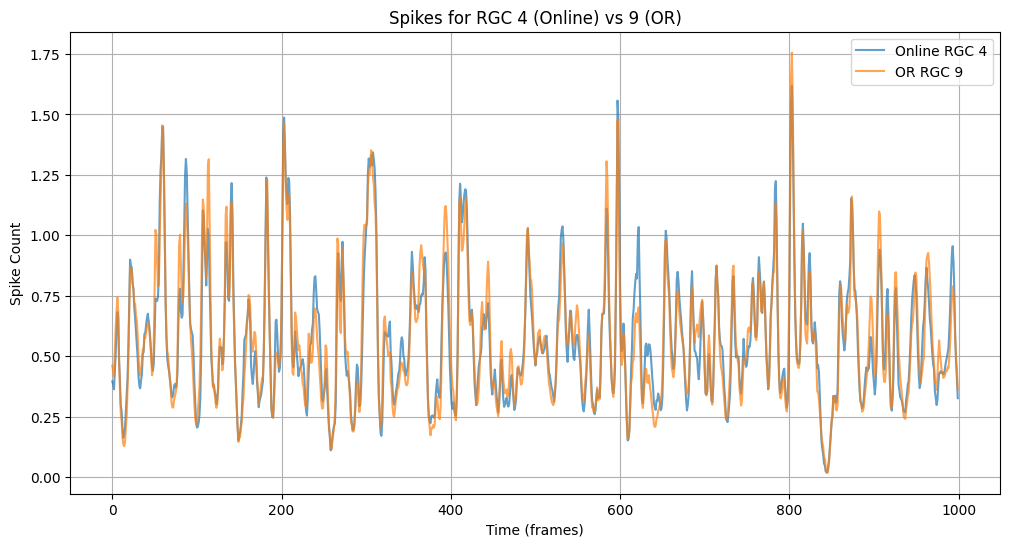

In [201]:

def compare_spikes(online_roi_id, or_roi_id):
    online_raw_session_dict = random_seed_mei_wrapper.session_dict_raw['online_session_1_ventral1_20250717']
    neuron_idx = np.where(raw_session_dict["roi_ids"]== or_roi_id)[0].item()
    online_neuron_idx = np.where( online_raw_session_dict["roi_ids"]== online_roi_id)[0].item()

    # extract the spikes 
    online_spikes = online_raw_session_dict["natural_spikes"][online_neuron_idx]
    or_spikes = raw_session_dict["natural_spikes"][neuron_idx]

    print(np.corrcoef(online_spikes[~ np.isnan(online_spikes)], or_spikes[~ np.isnan(or_spikes)])[0, 1])

    # plot them overlaid in one figure
    t0,t1 = 2000,3000
    plt.figure(figsize=(12, 6))
    plt.plot(online_spikes[t0:t1], label=f"Online RGC {online_roi_id}", alpha=0.7)
    plt.plot(or_spikes[t0:t1], label=f"OR RGC {or_roi_id}", alpha=0.7)

    plt.title(f"Spikes for RGC {online_roi_id} (Online) vs {or_roi_id} (OR)")
    plt.xlabel("Time (frames)")
    plt.ylabel("Spike Count")
    plt.legend()
    plt.grid()
    plt.show()

online_roi_id = 4
or_roi_id = 9 
compare_spikes(online_roi_id, or_roi_id)

Okay they seem to be veeeeery similar ... lets check online 41, 54 offline then the the MEIs 

0.9599009645150935


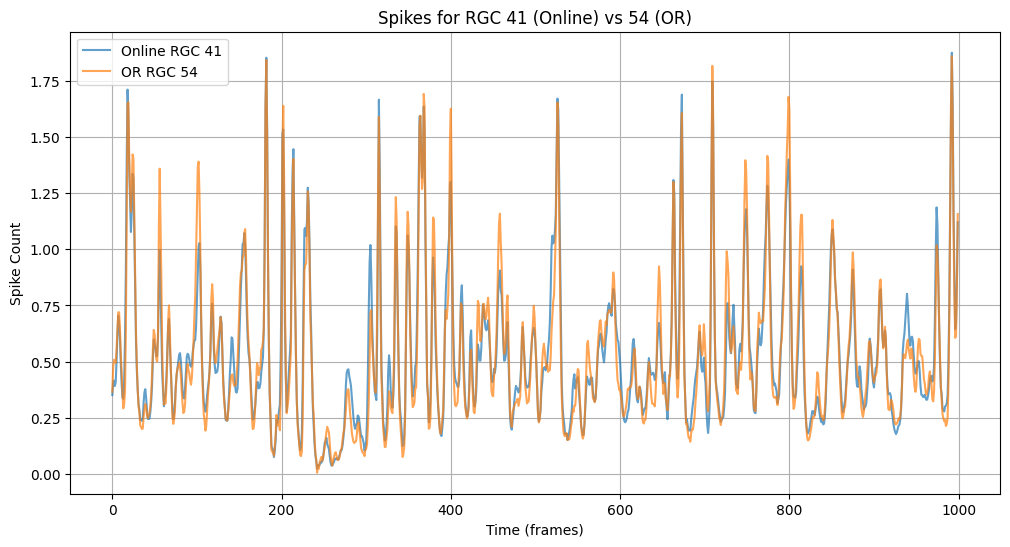

In [202]:
compare_spikes(online_roi_id=41, or_roi_id=54)

In [ ]:
# check if similar celltype assignment

def compare_celltypes(online_roi_id, or_roi_id):
    online_raw_session_dict = random_seed_mei_wrapper.session_dict_raw['online_session_1_ventral1_20250717']
    neuron_idx = np.where(raw_session_dict["roi_ids"]== or_roi_id)[0].item()
    online_neuron_idx = np.where( online_raw_session_dict["roi_ids"]== online_roi_id)[0].item()

    # extract the spikes 
    online_celltype = online_raw_session_dict["group_assignment"][online_neuron_idx]
    or_celltype = raw_session_dict["group_assignment"][neuron_idx]
    
    confidence_online = online_raw_session_dict["group_confidences"][online_neuron_idx].max()
    confidence_or = raw_session_dict["group_confidences"][neuron_idx].max()

    print(f"Online Celltype: {online_celltype} confidence {confidence_online}\nOR Celltype: {or_celltype}, confidence {confidence_or}")


compare_celltypes(online_roi_id, or_roi_id)

Online Celltype: 22 confidence 0.20290709247776015
OR Celltype: 22, confidence 0.38847899436950684


In [203]:
compare_celltypes(online_roi_id=41, or_roi_id=54)

Online Celltype: 17 confidence 0.5223695421015072
OR Celltype: 17, confidence 0.30858272314071655


# mei similarity

look at online 41 offline 54 because they are both not filtered

In [139]:
from simulations.loop_components.model_to_stimulus import (load_pretrained_model,
                                                           generate_optimization_components,
                                                           generate_mei,
                                                           decompose_mei,
                                                           Center)


In [ ]:
full_model_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/models/full/checkpoints/epoch=51_val_correlation=0.251.ckpt"

or_model = load_pretrained_model(full_model_path,)

In [137]:
# center readout 
center = Center(target_mean=0.0)
center(or_model)


In [ ]:
stimulus_postprocessor, response_reducer = generate_optimization_components()

offline_54_roi__mei = generate_mei(or_model,
             new_session_id='session_1_ventral1_20200226',
             stimulus_postprocessor=stimulus_postprocessor,
             response_reducer=response_reducer,
             )

In [144]:
temporal_kernels, spatial_kernels, stimulus_time = decompose_mei(roi_9_mei.detach().cpu().numpy())

In [148]:
from openretina.utils.plotting import play_stimulus, plot_stimulus_composition

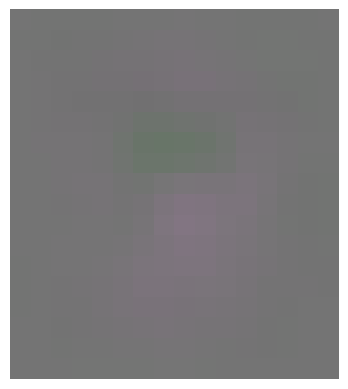

In [149]:
play_stimulus(roi_9_mei)

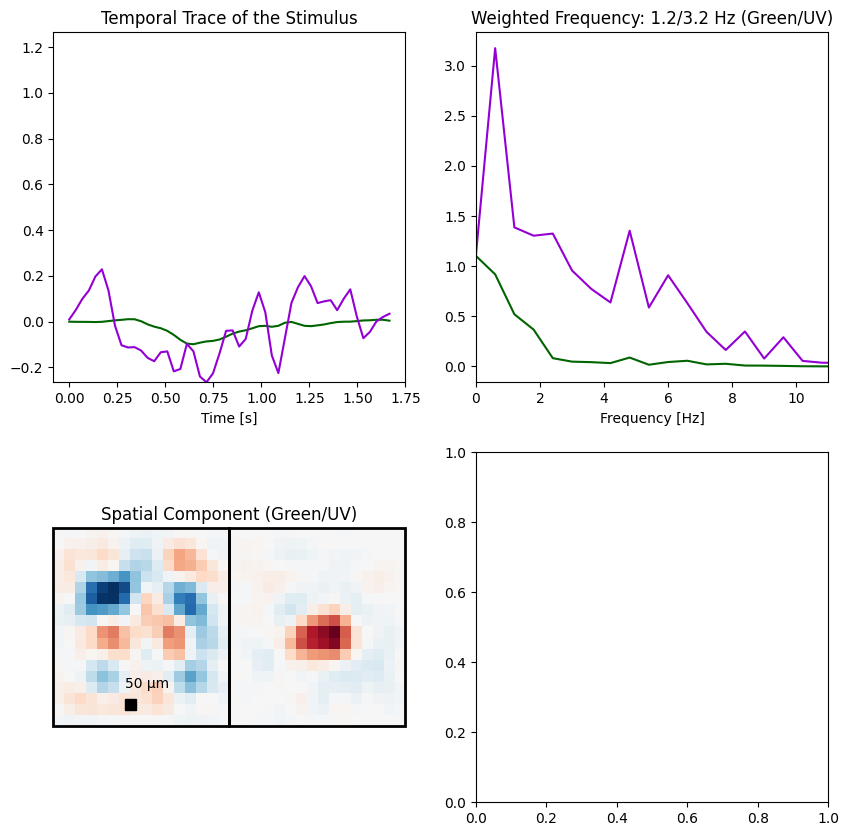

In [152]:
fig,ax = plt.subplots(2,2,figsize=(10, 10))
plot_stimulus_composition(roi_9_mei,ax[0,0],ax[0,1],ax[1,0],)

In [168]:
random_seed_mei_wrapper.neuron_data_dict['online_session_1_ventral1_20250717']

ResponsesTrainTestSplit(train=array([[0.52990256, 0.62538319, 0.76555503, ..., 2.10181469, 2.17767341,
        2.20388778],
       [0.63835867, 0.7166566 , 0.79687812, ..., 2.29366132, 1.99712052,
        1.76563656],
       [2.45976062, 2.26320215, 2.07912993, ..., 1.35134565, 1.37351317,
        1.36155423],
       ...,
       [0.86791033, 0.84158641, 0.83117012, ..., 1.06267785, 1.11649451,
        1.19075122],
       [2.52233109, 2.47689962, 2.39356101, ..., 1.62634232, 1.55111619,
        1.49737361],
       [0.70222265, 0.72272109, 0.76371102, ..., 0.54212826, 0.49992808,
        0.47306947]]), test_dict={'test': array([[1.05661904, 1.06389225, 1.05636561, ..., 0.36808725, 0.36085688,
        0.35706939],
       [1.30550657, 1.19758681, 1.09930731, ..., 0.57107072, 0.53028915,
        0.49637734],
       [1.77097905, 1.81613614, 1.85398125, ..., 1.75720207, 1.89302119,
        1.9854865 ],
       ...,
       [1.15330055, 1.13248177, 1.13095711, ..., 1.36351154, 1.35177108,
      

In [198]:
idx_in_model = random_seed_mei_wrapper.rois_after_filtering.index(41)
roi_4_mei = random_seed_mei_wrapper.neuron_seed_mei_dict[idx_in_model]

In [184]:
raw_session_dict["group_confidences"][8,:].max()

0.388479

In [169]:
dj_table_holder("CelltypeAssignment")()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),avg_stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,os_ds_stim_name Unique string identifier,training_data_hash hash of the classifier training data files,classifier_params_hash hash of the classifier params config,"celltype predicted group, without quality or confidence threshold",max_confidence confidence score for assigned celltype for easy restriction,confidence confidence score (probability) for all celltypes
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,1,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,46,0.227675,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,2,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,40,0.598459,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,3,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,7,0.136351,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,4,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,22,0.202907,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,5,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,1,0.367331,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,6,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,46,0.217036,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,7,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,17,0.43924,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,8,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,31,0.589163,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,9,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,14,0.177993,=BLOB=
closedlooptest,2025-07-17,1,1,GCL0,LR,iter0,gChirp,control,10,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,26,0.132294,=BLOB=
